In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, grangercausalitytests
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from scipy.stats import skew, kurtosis, shapiro
import warnings
import pmdarima as pm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
import statsmodels.stats.diagnostic as diag
import statsmodels.stats.proportion as prop
from datetime import datetime

# Ignore common warnings
warnings.filterwarnings('ignore')

# Set visualization styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (14, 7) # Larger default figure size
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12

In [3]:
# --- Step 1.1: Load & Verify Prep ---
# Load the dataset
file_path_filled = 'DC_Master_Data_Filled.csv'
df_filled = pd.read_csv(file_path_filled)

# Convert 'Date' column to datetime objects
df_filled['Date'] = pd.to_datetime(df_filled['Date'])

# Set 'Date' as the index
df_filled.set_index('Date', inplace=True)

In [4]:
# --- Step 1.2: Basic Information ---
print("\n--- Basic Information ---")
print(f"Shape of the DataFrame: {df_filled.shape}")
time_period = df_filled.index.max() - df_filled.index.min()
print(f"Time period covered: {df_filled.index.min().strftime('%Y-%m-%d')} to {df_filled.index.max().strftime('%Y-%m-%d')}")
print(f"Duration: {time_period.days} days")


--- Basic Information ---
Shape of the DataFrame: (140, 9)
Time period covered: 1990-01-01 to 2024-10-01
Duration: 12692 days


In [5]:
# --- Step 1.3: Descriptive Statistics ---
print("\n--- Descriptive Statistics ---")
desc_stats = df_filled.describe().T
# Calculate IQR
desc_stats['IQR'] = desc_stats['75%'] - desc_stats['25%']
# Calculate Coefficient of Variation (CV) = std / mean
desc_stats['CV'] = (desc_stats['std'] / desc_stats['mean']).abs()
# Calculate Skewness and Kurtosis
desc_stats['Skewness'] = df_filled.apply(skew)
desc_stats['Kurtosis'] = df_filled.apply(kurtosis) # Fisher’s definition (normal=0)
print(desc_stats[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'IQR', 'CV', 'Skewness', 'Kurtosis']])


--- Descriptive Statistics ---
                         count          mean           std           min  \
House_Index              140.0    205.550357     85.940726    100.000000   
CPI                      140.0    213.331111     50.484224    132.000000   
Poverty_Rate             140.0     12.980000      1.344243     10.500000   
Unemployment_Rate        140.0      5.711429      1.440278      2.600000   
Median_Household_Income  140.0  77782.821429  18003.414039  53450.000000   
Population               140.0   5363.002787    745.377352   4088.514122   
Interest_Rate            140.0      2.844429      2.381055      0.050000   
Mortgage_Rate            140.0      6.004671      1.880658      2.735000   
GDP                      140.0  14572.347771   6301.461511   5872.701000   

                                  25%           50%           75%  \
House_Index                107.165000    214.405000    266.237500   
CPI                        164.887500    216.237000    252.326375   


In [6]:
# --- Step 1.4: Outlier Detection (IQR Method) ---
print("\n--- Outlier Detection (IQR Method) ---")
outliers_summary = {}
for column in df_filled.columns:
    Q1 = df_filled[column].quantile(0.25)
    Q3 = df_filled[column].quantile(0.75)
    IQR_val = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR_val
    upper_bound = Q3 + 1.5 * IQR_val

    # Identify outliers
    outliers = df_filled[(df_filled[column] < lower_bound) | (df_filled[column] > upper_bound)]
    if not outliers.empty:
        outliers_summary[column] = {
            'count': len(outliers),
            'indices': outliers.index.strftime('%Y-%m-%d').tolist(),
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        }
        print(f"Potential outliers found in '{column}': {len(outliers)}")
        # print(f"  Indices: {outliers.index.strftime('%Y-%m-%d').tolist()}")
        # print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    else:
        print(f"No potential outliers found in '{column}' based on IQR.")
        outliers_summary[column] = {'count': 0}


--- Outlier Detection (IQR Method) ---
No potential outliers found in 'House_Index' based on IQR.
No potential outliers found in 'CPI' based on IQR.
No potential outliers found in 'Poverty_Rate' based on IQR.
Potential outliers found in 'Unemployment_Rate': 2
No potential outliers found in 'Median_Household_Income' based on IQR.
No potential outliers found in 'Population' based on IQR.
No potential outliers found in 'Interest_Rate' based on IQR.
No potential outliers found in 'Mortgage_Rate' based on IQR.
No potential outliers found in 'GDP' based on IQR.


In [7]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['House_Index']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")

# --- Continue with your next steps ---


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=728.863, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=833.530, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=717.487, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=733.118, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=855.811, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=752.226, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[4] intercept   : AIC=719.253, Time=0.05 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=719.305, Time=0.04 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=727.060, Time=0.03 sec
 ARIMA(1,1,0)(2,0,1)[4] intercept   : AIC=721.106, Time=0.09 sec
 ARIMA(0,1,0)(1,0,0)[4] intercept   : AIC=775.009, Time=0.02 sec
 ARIMA(2,1,0)(1,0,0)[4] intercept   : AIC=719.402, Time=0.04 sec
 ARIMA(1,1,1)(1,0,0)[4] intercept   : AIC=719.283, Time=0.04 sec
 ARIMA(0,1,1)(1,0,0)[4] intercept   : AIC=724.933, Time=0.03 sec
 ARIMA(2,1,1)(1,0,0

In [8]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Step 2: Define and Fit the SARIMA Model ---
# Model parameters identified by auto_arima
order = (3, 1, 2)
seasonal_order = (1, 0, 0, 4)

print(f"Fitting SARIMA{order}x{seasonal_order} model...")

# Define the model using statsmodels
# trend='c' includes a constant intercept, similar to auto_arima's behavior
model = SARIMAX(house_index_series,
                order=order,
                seasonal_order=seasonal_order,
                trend='c',
                enforce_stationarity=False, # Often needed for higher orders
                enforce_invertibility=False) # Often needed for higher orders

# Fit the model
results = model.fit(disp=False) # disp=False hides convergence output
print("Model fitting complete.")
# Optional: print summary to check coefficients if desired
# print(results.summary())

# --- Step 3: Generate Forecasts ---
# Forecast 3 steps ahead for 2025-01-01, 2025-04-01, 2025-07-01
n_steps = 3
print(f"Generating {n_steps}-step ahead forecast...")
forecast_object = results.get_forecast(steps=n_steps)

# Extract point forecasts
point_forecasts = forecast_object.predicted_mean

# Extract confidence intervals (optional)
conf_int = forecast_object.conf_int(alpha=0.05) # 95% confidence interval

# Combine forecasts and confidence intervals into a DataFrame for nice display
forecast_df = pd.DataFrame({
    'Forecast': point_forecasts,
    'Lower 95% CI': conf_int.iloc[:, 0],
    'Upper 95% CI': conf_int.iloc[:, 1]
})

# --- Step 4: Display Forecasts ---
print("\n--- Baseline SARIMA Forecasts for House_Index ---")
print(forecast_df)

Fitting SARIMA(3, 1, 2)x(1, 0, 0, 4) model...
Model fitting complete.
Generating 3-step ahead forecast...

--- Baseline SARIMA Forecasts for House_Index ---
              Forecast  Lower 95% CI  Upper 95% CI
2025-01-01  398.777236    392.859979    404.694493
2025-04-01  408.437083    397.238115    419.636052
2025-07-01  409.477240    393.816292    425.138188


Loading data from DC_Master_Data_With_Dummies.csv...
Data loaded successfully.
Using 'House_Index' series up to 2024-10-01. Shape: (140,)
Test series starts from 2016-01-01. Shape: (36,)
Performing 1-step ahead rolling forecast...
  Forecasting step 1/36 (Date: 2016-01-01)
  Forecasting step 11/36 (Date: 2018-07-01)
  Forecasting step 21/36 (Date: 2021-01-01)
  Forecasting step 31/36 (Date: 2023-07-01)
  Forecasting step 36/36 (Date: 2024-10-01)

--- 1-Step Ahead Forecast Evaluation Metrics ---
Mean Absolute Error (MAE):       2.988
Root Mean Squared Error (RMSE):  4.369
Mean Absolute Percentage Error (MAPE): 0.009
Directional Accuracy (%):        80.6
Performing 2-step ahead rolling forecast...
  Forecasting step 1/35 (Date: 2016-01-01)
  Forecasting step 11/35 (Date: 2018-07-01)
  Forecasting step 21/35 (Date: 2021-01-01)
  Forecasting step 31/35 (Date: 2023-07-01)
  Forecasting step 35/35 (Date: 2024-07-01)

--- 2-Step Ahead Forecast Evaluation Metrics ---
Mean Absolute Error (MAE):

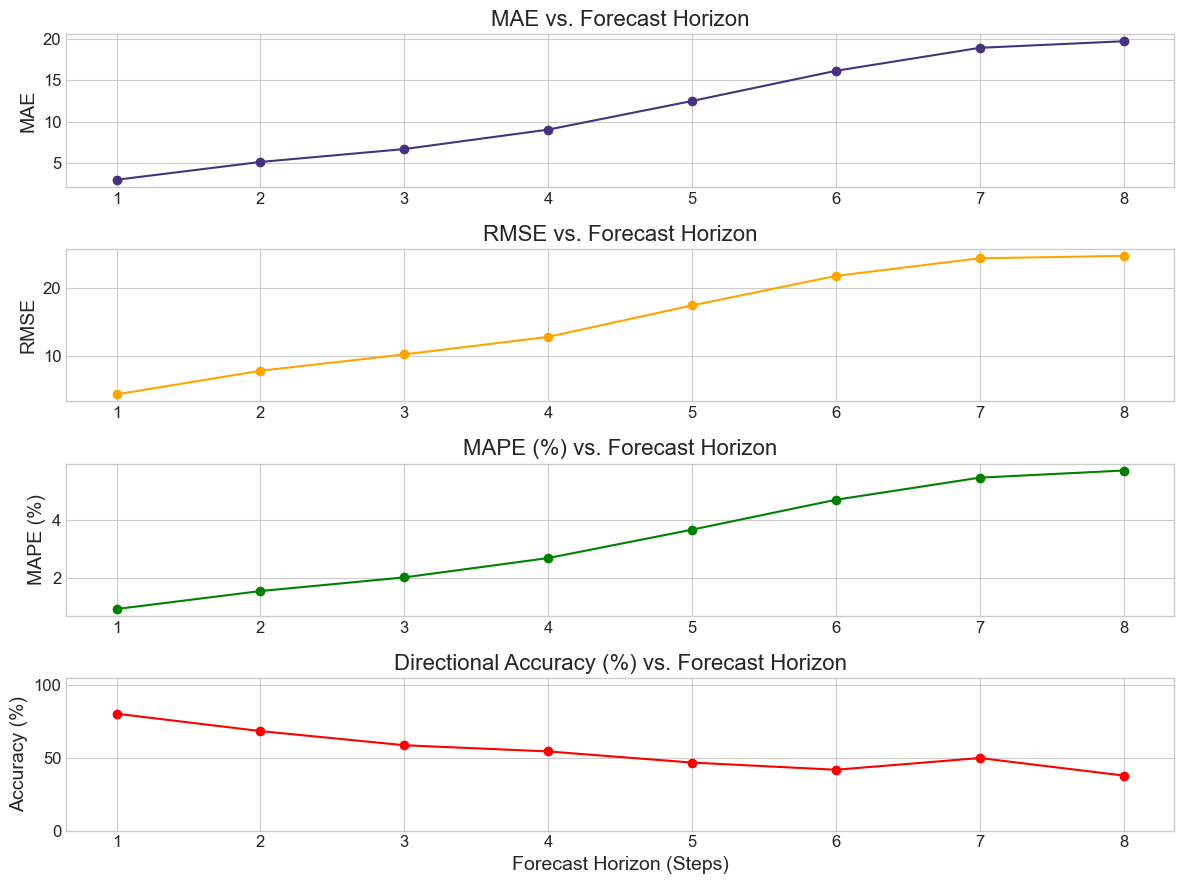

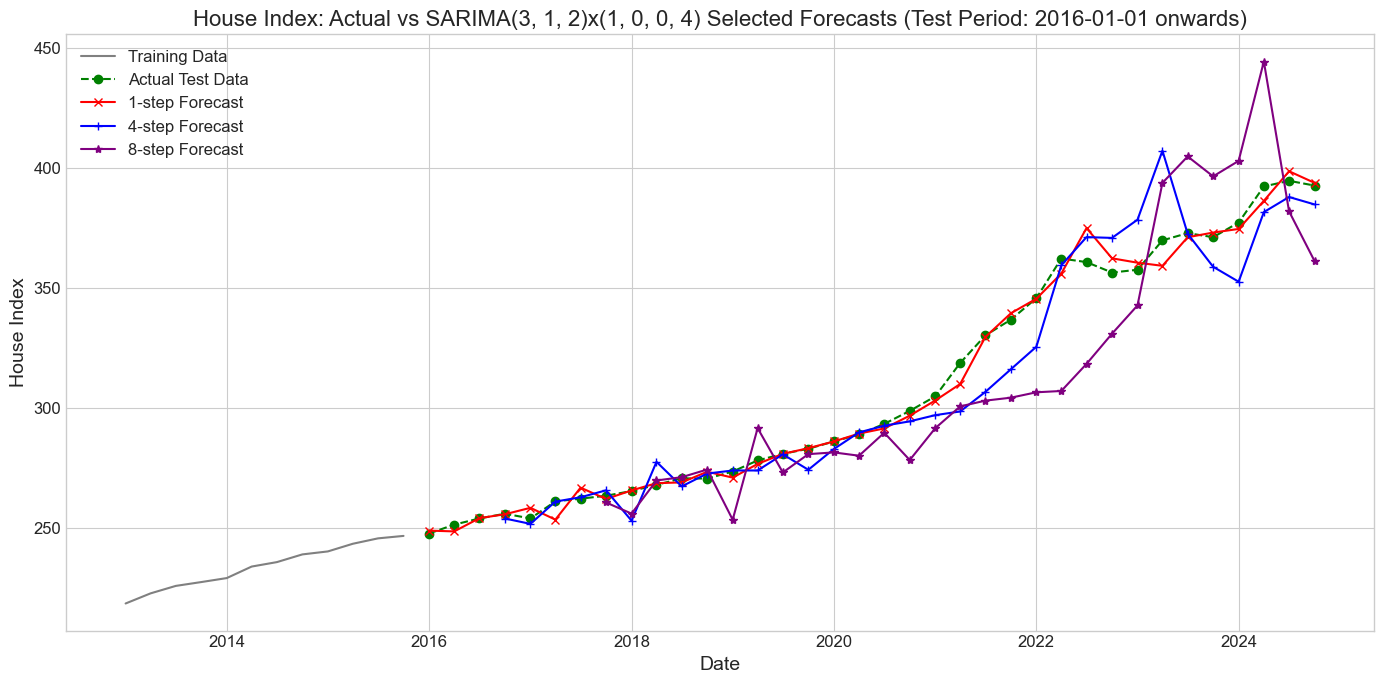

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import warnings

# Suppress convergence and other warnings for cleaner output
warnings.filterwarnings("ignore")

# --- Configuration ---
input_file = 'DC_Master_Data_With_Dummies.csv'
target_column = 'House_Index'
test_start_date = '2016-01-01'
model_order = (3, 1, 2)
seasonal_order = (1, 0, 0, 4)
trend = 'c'
max_forecast_horizon = 8
series_end_date = '2024-10-01'

# --- Load Data ---
print(f"Loading data from {input_file}...")
try:
    df_master = pd.read_csv(input_file, parse_dates=['Date'], index_col='Date')
    print("Data loaded successfully.")

    if target_column not in df_master.columns:
        raise KeyError(f"Target column '{target_column}' not found.")

    house_index_series = df_master[target_column].loc[df_master.index <= series_end_date].copy()
    print(f"Using '{target_column}' series up to {series_end_date}. Shape: {house_index_series.shape}")

    test_series = house_index_series[house_index_series.index >= test_start_date]
    if test_series.empty:
        raise ValueError("Test series is empty. Check test_start_date and data range.")
    print(f"Test series starts from {test_start_date}. Shape: {test_series.shape}")

    # --- Function to perform rolling forecast (MODIFIED) ---
    def perform_rolling_forecast(series, test_series, start_date, steps_ahead, order, seasonal_order, trend):
        history = series[series.index < start_date].copy()
        predictions = []
        actuals = []

        print(f"Performing {steps_ahead}-step ahead rolling forecast...")
        forecast_end_index_limit = len(test_series) - steps_ahead
        if forecast_end_index_limit < 0:
             print(f"Warning: Not enough data points in the test set to perform a {steps_ahead}-step ahead forecast.")
             return None, None
        forecast_dates = test_series.index[:forecast_end_index_limit + 1]

        for t, current_date in enumerate(forecast_dates):
            if t % 10 == 0 or t == len(forecast_dates) - 1:
                 print(f"  Forecasting step {t+1}/{len(forecast_dates)} (Date: {current_date.strftime('%Y-%m-%d')})")

            model = SARIMAX(
                history, order=order, seasonal_order=seasonal_order, trend=trend,
                enforce_stationarity=False, enforce_invertibility=False
            )
            results = model.fit(disp=False)
            forecast_object = results.get_forecast(steps=steps_ahead)
            yhat = forecast_object.predicted_mean.iloc[steps_ahead-1]
            predictions.append(yhat)
            actual_date_index = t + steps_ahead -1
            actual = test_series.iloc[actual_date_index]
            actuals.append(actual)
            history = series[series.index <= current_date]

        results_df = pd.DataFrame(
            {'Actual': actuals, f'Forecast ({steps_ahead}-step)': predictions},
            index=test_series.index[steps_ahead-1 : len(predictions) + steps_ahead - 1]
        )

        # --- Calculate Metrics (Added Directional Accuracy) ---
        mae = mean_absolute_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])
        mse = mean_squared_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])
        rmse = np.sqrt(mse)

        # Calculate MAPE carefully
        if np.any(results_df['Actual'] == 0):
             print(f"Warning: Actual values contain zeros at horizon {steps_ahead}. MAPE might be misleading or infinite.")
             non_zero_actuals = results_df['Actual'][results_df['Actual'] != 0]
             non_zero_preds = results_df[f'Forecast ({steps_ahead}-step)'][results_df['Actual'] != 0]
             mape = np.mean(np.abs((non_zero_actuals - non_zero_preds) / non_zero_actuals)) if len(non_zero_actuals) > 0 else np.nan
        else:
             mape = mean_absolute_percentage_error(results_df['Actual'], results_df[f'Forecast ({steps_ahead}-step)'])

        # Calculate Directional Accuracy
        # Get previous actual value corresponding to each forecast date
        results_df['Actual_Previous'] = series.shift(1).reindex(results_df.index)
        # Calculate actual change from previous period
        results_df['Actual_Change'] = results_df['Actual'] - results_df['Actual_Previous']
        # Calculate predicted change from previous period
        results_df['Predicted_Change'] = results_df[f'Forecast ({steps_ahead}-step)'] - results_df['Actual_Previous']

        # Drop rows where changes couldn't be calculated (first row)
        valid_comparison = results_df[['Actual_Change', 'Predicted_Change']].dropna()

        # Compare signs (True if signs match and are non-zero, or both are zero)
        # np.sign returns -1, 0, 1
        correct_direction = (np.sign(valid_comparison['Actual_Change']) == np.sign(valid_comparison['Predicted_Change']))
        directional_accuracy = correct_direction.mean() * 100 if not correct_direction.empty else np.nan


        print(f"\n--- {steps_ahead}-Step Ahead Forecast Evaluation Metrics ---")
        print(f"Mean Absolute Error (MAE):       {mae:.3f}")
        print(f"Root Mean Squared Error (RMSE):  {rmse:.3f}")
        print(f"Mean Absolute Percentage Error (MAPE): {mape:.3f}")
        print(f"Directional Accuracy (%):        {directional_accuracy:.1f}") # Added

        metrics = {'MAE': mae, 'RMSE': rmse, 'MAPE': mape*100, 'Directional Accuracy (%)': directional_accuracy} # Added Dir Acc
        return results_df, metrics

    # --- Run forecasts for horizons 1 through max_forecast_horizon ---
    all_results_dfs = {}
    all_metrics = {}

    for h in range(1, max_forecast_horizon + 1):
        results_df, metrics = perform_rolling_forecast(
            house_index_series, test_series, test_start_date, h,
            model_order, seasonal_order, trend
        )
        if results_df is not None:
            all_results_dfs[h] = results_df
            all_metrics[h] = metrics
        else:
            print(f"Could not generate results for {h}-step ahead forecast.")
            break # Stop if forecast cannot be generated

    # --- Consolidate and Compare Metrics (MODIFIED) ---
    if all_metrics:
        metrics_comparison_df = pd.DataFrame(all_metrics).T
        metrics_comparison_df.index.name = 'Forecast Horizon (Steps)'
        print("\n--- Comparison of Metrics Across Forecast Horizons ---")
        print(metrics_comparison_df.to_markdown(floatfmt=".3f")) # Incl Dir Acc

        # --- Plot Metrics vs. Forecast Horizon (MODIFIED - 4 subplots) ---
        plt.figure(figsize=(12, 9)) # Increased height for 4 plots

        plt.subplot(4, 1, 1)
        plt.plot(metrics_comparison_df.index, metrics_comparison_df['MAE'], marker='o')
        plt.title('MAE vs. Forecast Horizon')
        plt.ylabel('MAE')
        plt.xticks(metrics_comparison_df.index)
        plt.grid(True)

        plt.subplot(4, 1, 2)
        plt.plot(metrics_comparison_df.index, metrics_comparison_df['RMSE'], marker='o', color='orange')
        plt.title('RMSE vs. Forecast Horizon')
        plt.ylabel('RMSE')
        plt.xticks(metrics_comparison_df.index)
        plt.grid(True)

        plt.subplot(4, 1, 3)
        plt.plot(metrics_comparison_df.index, metrics_comparison_df['MAPE'], marker='o', color='green')
        plt.title('MAPE (%) vs. Forecast Horizon')
        plt.ylabel('MAPE (%)')
        plt.xticks(metrics_comparison_df.index)
        plt.grid(True)

        plt.subplot(4, 1, 4) # Added subplot for Directional Accuracy
        plt.plot(metrics_comparison_df.index, metrics_comparison_df['Directional Accuracy (%)'], marker='o', color='red')
        plt.title('Directional Accuracy (%) vs. Forecast Horizon')
        plt.ylabel('Accuracy (%)')
        plt.xlabel('Forecast Horizon (Steps)')
        plt.xticks(metrics_comparison_df.index)
        plt.ylim(0, 105) # Set y-axis limits for accuracy (0-100%)
        plt.grid(True)

        plt.tight_layout()
        plt.show()

        # --- Plot Actual vs Select Forecasts (Unchanged) ---
        plt.figure(figsize=(14, 7))
        viz_start_date = '2013-01-01'
        historical_subset = house_index_series[(house_index_series.index < test_start_date) & (house_index_series.index >= viz_start_date)]
        plt.plot(historical_subset.index, historical_subset, label='Training Data', color='grey')
        plt.plot(test_series.index, test_series, label='Actual Test Data', color='green', marker='o', linestyle='--')
        horizons_to_plot = [1, 4, 8]
        colors = ['red', 'blue', 'purple']
        markers = ['x', '+', '*']
        for i, h in enumerate(horizons_to_plot):
            if h in all_results_dfs:
                plt.plot(all_results_dfs[h].index, all_results_dfs[h][f'Forecast ({h}-step)'],
                         label=f'{h}-step Forecast', color=colors[i % len(colors)],
                         marker=markers[i % len(markers)], linestyle='-')
        plt.title(f'House Index: Actual vs SARIMA{model_order}x{seasonal_order} Selected Forecasts (Test Period: {test_start_date} onwards)')
        plt.xlabel('Date')
        plt.ylabel('House Index')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    else:
        print("\nNo metrics were generated.")


except FileNotFoundError:
    print(f"Error: The file '{input_file}' was not found.")
except KeyError as e:
    print(f"Error: Problem accessing column: {e}")
except ValueError as e:
     print(f"ValueError: {e}")
except Exception as e:
    print(f"An unexpected error occurred during analysis: {e}")

In [10]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['CPI']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=516.959, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=526.153, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=510.988, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=515.110, Time=0.02 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=598.513, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=524.500, Time=0.01 sec
 ARIMA(1,1,0)(2,0,0)[4] intercept   : AIC=507.494, Time=0.05 sec
 ARIMA(1,1,0)(2,0,1)[4] intercept   : AIC=505.636, Time=0.23 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=504.879, Time=0.07 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=515.343, Time=0.03 sec
 ARIMA(1,1,0)(1,0,2)[4] intercept   : AIC=505.951, Time=0.17 sec
 ARIMA(1,1,0)(0,0,2)[4] intercept   : AIC=512.194, Time=0.04 sec
 ARIMA(1,1,0)(2,0,2)[4] intercept   : AIC=507.030, Time=0.23 sec
 ARIMA(0,1,0)(1,0,1)[4] intercept   : AIC=508.216, Time=0.05 sec
 ARIMA(2,1,0)(1,0,1

In [11]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Poverty_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=-326.058, Time=0.12 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=-138.307, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=-322.831, Time=0.07 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=-253.497, Time=0.07 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=-138.351, Time=0.01 sec
 ARIMA(1,1,1)(0,0,0)[4] intercept   : AIC=-314.684, Time=0.04 sec
 ARIMA(1,1,1)(1,0,1)[4] intercept   : AIC=inf, Time=0.19 sec
 ARIMA(1,1,1)(0,0,2)[4] intercept   : AIC=inf, Time=0.30 sec
 ARIMA(1,1,1)(1,0,0)[4] intercept   : AIC=-321.202, Time=0.10 sec
 ARIMA(1,1,1)(1,0,2)[4] intercept   : AIC=inf, Time=0.27 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=-327.877, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=-315.954, Time=0.02 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.18 sec
 ARIMA(1,1,0)(0,0,2)[4] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,1,0)(1,0,2)[4] interc

In [12]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Unemployment_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,0,1)[4] intercept   : AIC=310.153, Time=0.13 sec
 ARIMA(0,0,0)(0,0,0)[4] intercept   : AIC=502.453, Time=0.01 sec
 ARIMA(1,0,0)(1,0,0)[4] intercept   : AIC=303.964, Time=0.10 sec
 ARIMA(0,0,1)(0,0,1)[4] intercept   : AIC=379.430, Time=0.05 sec
 ARIMA(0,0,0)(0,0,0)[4]             : AIC=895.766, Time=0.00 sec
 ARIMA(1,0,0)(0,0,0)[4] intercept   : AIC=325.864, Time=0.02 sec
 ARIMA(1,0,0)(2,0,0)[4] intercept   : AIC=303.276, Time=0.14 sec
 ARIMA(1,0,0)(2,0,1)[4] intercept   : AIC=inf, Time=0.20 sec
 ARIMA(1,0,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(0,0,0)(2,0,0)[4] intercept   : AIC=437.356, Time=0.11 sec
 ARIMA(2,0,0)(2,0,0)[4] intercept   : AIC=305.237, Time=0.23 sec
 ARIMA(1,0,1)(2,0,0)[4] intercept   : AIC=305.255, Time=0.18 sec
 ARIMA(0,0,1)(2,0,0)[4] intercept   : AIC=367.500, Time=0.14 sec
 ARIMA(2,0,1)(2,0,0)[4] intercept   : AIC=285.458, Time=0.27 sec
 ARIMA(2,0,1)(1,0,0)[4] int

In [13]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Population']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=808.784, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=1011.370, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=808.651, Time=0.05 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=878.577, Time=0.05 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=1217.521, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=811.691, Time=0.02 sec
 ARIMA(1,1,0)(2,0,0)[4] intercept   : AIC=809.918, Time=0.10 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=inf, Time=0.14 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=806.898, Time=0.04 sec
 ARIMA(1,1,0)(0,0,2)[4] intercept   : AIC=802.701, Time=0.08 sec
 ARIMA(1,1,0)(1,0,2)[4] intercept   : AIC=inf, Time=0.22 sec
 ARIMA(0,1,0)(0,0,2)[4] intercept   : AIC=962.289, Time=0.05 sec
 ARIMA(2,1,0)(0,0,2)[4] intercept   : AIC=804.682, Time=0.09 sec
 ARIMA(1,1,1)(0,0,2)[4] intercept   : AIC=804.683, Time=0.10 sec
 ARIMA(0,1,1)(0,0,2)[4] i

In [14]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Interest_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=111.234, Time=0.06 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=185.477, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=110.135, Time=0.04 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=136.889, Time=0.04 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=183.861, Time=0.01 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=108.190, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1)[4] intercept   : AIC=110.141, Time=0.03 sec
 ARIMA(1,1,0)(1,0,1)[4] intercept   : AIC=112.044, Time=0.09 sec
 ARIMA(2,1,0)(0,0,0)[4] intercept   : AIC=109.202, Time=0.03 sec
 ARIMA(1,1,1)(0,0,0)[4] intercept   : AIC=109.406, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[4] intercept   : AIC=136.763, Time=0.02 sec
 ARIMA(2,1,1)(0,0,0)[4] intercept   : AIC=110.959, Time=0.08 sec
 ARIMA(1,1,0)(0,0,0)[4]             : AIC=106.314, Time=0.01 sec
 ARIMA(1,1,0)(1,0,0)[4]             : AIC=108.262, Time=0.02 sec
 ARIMA(1,1,0)(0,0,1

In [15]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['Mortgage_Rate']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,1,1)(0,0,1)[4] intercept   : AIC=165.697, Time=0.11 sec
 ARIMA(0,1,0)(0,0,0)[4] intercept   : AIC=160.673, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[4] intercept   : AIC=163.712, Time=0.03 sec
 ARIMA(0,1,1)(0,0,1)[4] intercept   : AIC=163.733, Time=0.03 sec
 ARIMA(0,1,0)(0,0,0)[4]             : AIC=159.151, Time=0.01 sec
 ARIMA(0,1,0)(1,0,0)[4] intercept   : AIC=162.628, Time=0.02 sec
 ARIMA(0,1,0)(0,0,1)[4] intercept   : AIC=162.632, Time=0.02 sec
 ARIMA(0,1,0)(1,0,1)[4] intercept   : AIC=164.134, Time=0.05 sec
 ARIMA(1,1,0)(0,0,0)[4] intercept   : AIC=161.728, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[4] intercept   : AIC=161.746, Time=0.02 sec
 ARIMA(1,1,1)(0,0,0)[4] intercept   : AIC=163.715, Time=0.03 sec

Best model:  ARIMA(0,1,0)(0,0,0)[4]          
Total fit time: 0.355 seconds

--- Auto ARIMA Model Summary ---
                               SARIMAX Results                                
Dep. Variable:          

In [16]:
print("\n--- Running Auto ARIMA ---")
# Select the target variable (ensure df_filled is indexed by Date)
house_index_series = df_filled['GDP']

# Run auto_arima
auto_arima_model = pm.auto_arima(house_index_series,
                                    start_p=1, start_q=1,
                                    max_p=3, max_q=3,     # Limit complexity slightly
                                    m=4,                 # Frequency of the series (4 for quarterly)
                                    start_P=0,           # Start P for seasonal
                                    seasonal=True,       # Test for seasonality
                                    d=None,              # Let auto_arima determine 'd' automatically
                                    D=None,              # Let auto_arima determine 'D' automatically
                                    trace=True,          # Print models tested
                                    error_action='ignore', # Don't stop on errors from specific orders
                                    suppress_warnings=True, # Don't print convergence warnings
                                    stepwise=True)       # Use stepwise algorithm for faster search

# Print the summary of the best model found
print("\n--- Auto ARIMA Model Summary ---")
print(auto_arima_model.summary())

# You can also access the order directly
print(f"\nBest model order (p,d,q): {auto_arima_model.order}")
print(f"Best seasonal order (P,D,Q,m): {auto_arima_model.seasonal_order}")


--- Running Auto ARIMA ---
Performing stepwise search to minimize aic
 ARIMA(1,2,1)(0,0,1)[4]             : AIC=1929.642, Time=0.06 sec
 ARIMA(0,2,0)(0,0,0)[4]             : AIC=2022.854, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[4]             : AIC=1972.803, Time=0.02 sec
 ARIMA(0,2,1)(0,0,1)[4]             : AIC=1929.325, Time=0.04 sec
 ARIMA(0,2,1)(0,0,0)[4]             : AIC=1927.344, Time=0.02 sec
 ARIMA(0,2,1)(1,0,0)[4]             : AIC=1929.327, Time=0.04 sec
 ARIMA(0,2,1)(1,0,1)[4]             : AIC=inf, Time=0.05 sec
 ARIMA(1,2,1)(0,0,0)[4]             : AIC=1927.665, Time=0.03 sec
 ARIMA(0,2,2)(0,0,0)[4]             : AIC=1927.799, Time=0.03 sec
 ARIMA(1,2,0)(0,0,0)[4]             : AIC=1970.903, Time=0.01 sec
 ARIMA(1,2,2)(0,0,0)[4]             : AIC=1929.614, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[4] intercept   : AIC=1927.214, Time=0.05 sec
 ARIMA(0,2,1)(1,0,0)[4] intercept   : AIC=1929.208, Time=0.06 sec
 ARIMA(0,2,1)(0,0,1)[4] intercept   : AIC=1929.207, Time=0.08 sec
 ARIMA(0,2

This notebook focused on the initial exploration and univariate time series analysis of the DC economic and housing dataset spanning from 1990-01-01 to 2024-10-01.

1. Data Overview:

The dataset comprises 9 variables recorded quarterly over nearly 35 years.
Descriptive statistics revealed varying scales and distributions across variables. IQR outlier detection flagged only 2 potential outliers in Unemployment_Rate.
2. Univariate Time Series Analysis (auto_arima):
auto_arima was applied to each variable individually to identify the best-fitting SARIMA model based on AIC. Key findings include:

Stationarity: Most variables required differencing to achieve stationarity, typically first-order differencing (I(1)). GDP notably required second-order differencing (I(2)), while Unemployment_Rate was found to be stationary (I(0)).
I(1): House_Index, CPI, Poverty_Rate, Population, Interest_Rate, Mortgage_Rate (Random Walk)
I(0): Unemployment_Rate
I(2): GDP
Seasonality: Evidence of quarterly seasonality (m=4) was detected in House_Index (weak AR), CPI (strong AR/MA), Poverty_Rate (MA), Unemployment_Rate (AR), and Population (MA). Interest_Rate, Mortgage_Rate, and GDP models showed no seasonality.
Model Complexity: The identified models varied in complexity, from a simple random walk for Mortgage_Rate to more complex ARMA structures for House_Index and Unemployment_Rate.
Residual Diagnostics: While auto_arima optimizes for fit (AIC), the summaries revealed common issues in residuals for many variables: significant non-normality (high Kurtosis) and heteroskedasticity (non-constant variance). This is typical for economic data but should be kept in mind when evaluating model reliability, especially for confidence intervals.
3. Baseline Forecasting (House_Index):
The optimal univariate model for House_Index, SARIMA(3, 1, 2)x(1, 0, 0)[4], was evaluated:

Static Forecast: Training once and forecasting the entire test period (2023-2024) yielded a MAPE of ~4.8%.
Rolling Forecast: A more realistic evaluation, refitting the model at each step with updated data:
1-Step Ahead: Achieved excellent accuracy with a MAPE of ~1.0%.
2-Steps Ahead: Accuracy decreased (MAPE ~1.8%), demonstrating error accumulation over longer horizons.
4. Conclusions & Next Steps:

The House_Index exhibits a clear trend (requiring differencing) and complex autoregressive patterns. The univariate SARIMA model provides a strong baseline for short-term (1-quarter ahead) forecasting when regularly updated.
Most potential predictors are also non-stationary and require differencing. Their individual auto_arima models provide insights into their own dynamics.
The presence of non-normality and heteroskedasticity in residuals is noted and may warrant consideration in advanced modeling stages.
The next phase should focus on multivariate analysis by:
Formally confirming stationarity with ADF/KPSS tests.
Analyzing correlations, cointegration (Johansen test, given multiple I(1) series), and lead/lag relationships (CCF, Granger causality) using the stationary (differenced) data.
Building and evaluating multivariate models (e.g., VAR, VECM, SARIMAX with exogenous variables, ML models) to see if incorporating predictor information can improve forecast accuracy, particularly for multi-step ahead forecasts, compared to the univariate baseline.
